# Эксперимент 3.2 — доля строгих нулей

Подбираем $\lambda$ так, чтобы у разрежённого решения FISTA было примерно **50–80%** точных нулей, затем сравниваем **субградиент**, **FISTA**, **Frank–Wolfe** (на согласованном $R$) и **метод барьеров** с $x_0=0$.  
По оси Y — доля компонент с $|x_i|<10^{-8}$ (для проксимальных методов нули обычно машинные `0.0`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents][:12]:
        if (p / "src" / "optimization.py").is_file():
            return p
    return here


ROOT = _find_repo_root()
sys.path.insert(0, str(ROOT))

from src.counted_oracle import CountedCompositeOracle, CountedNonsmoothOracle, CountedSmoothOracle
from src.experiment_utils import (
    radius_from_reference,
    synthetic_classification,
    synthetic_regression,
    tune_lambda_for_zero_fraction,
)
from src.oracles import ClassificationNonsmoothOracle, ClassificationProxOracle, RegressionNonsmoothOracle, RegressionProxOracle
from src.optimization import (
    barrier_method,
    frank_wolfe_method,
    proximal_fast_gradient_method,
    subgradient_method,
)
from src.paths import figs_dir

FIG = figs_dir()
ZERO_THRESH = 1e-8
rng = np.random.default_rng(7)

Подобрано λ = 0.008891397050194616 R = 3.717707646186716 нулей в ref: 0.575


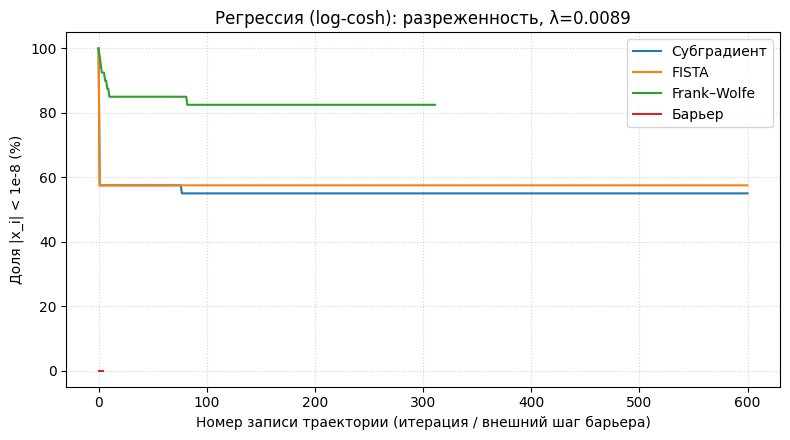

Сохранено C:\Users\axmed\OneDrive\Рабочий стол\proj\NothingElseMatters\figs\exp32_sparsity_regression.png


In [2]:
def run_four_methods_regression(m=120, n=40, max_iter=600, max_barrier_outer=35):
    A, b, _ = synthetic_regression(m, n, rng, sparsity=0.65)
    x0 = np.zeros(n)

    def build(lam):
        return RegressionProxOracle(A, b, lam, l2_reg=0.0)

    lam, xref = tune_lambda_for_zero_fraction(
        build, n, x0, target_low=0.52, target_high=0.78, max_iter_fista=3500
    )
    R = radius_from_reference(xref, scale=1.04)
    print("Подобрано λ =", lam, "R =", R, "нулей в ref:", np.mean(np.abs(xref) < 1e-12))

    comp = CountedCompositeOracle(RegressionProxOracle(A, b, lam, l2_reg=0.0))
    nons = CountedNonsmoothOracle(RegressionNonsmoothOracle(A, b, lam, l2_reg=0.0))
    sm = CountedSmoothOracle(RegressionProxOracle(A, b, lam, l2_reg=0.0).smooth)

    h = {}
    _, _, h["subgrad"] = subgradient_method(
        nons, x0, max_iter=max_iter, alpha_0=0.4, trace=True, zero_thresh=ZERO_THRESH
    )
    _, _, h["fista"] = proximal_fast_gradient_method(
        comp, x0, max_iter=max_iter, tolerance=1e-12, trace=True, zero_thresh=ZERO_THRESH
    )
    _, _, h["fw"] = frank_wolfe_method(
        sm,
        x0,
        R,
        max_iter=max_iter,
        step_size_strategy="armijo",
        trace=True,
        lambda_l1=lam,
        zero_thresh=ZERO_THRESH,
    )
    u0 = np.abs(x0) + 1.0
    _, _, h["barrier"] = barrier_method(
        sm,
        x0,
        u0,
        lam,
        t_0=1.0,
        mu=8.0,
        max_iter=max_barrier_outer,
        max_inner_iter=80,
        tolerance_inner=5e-5,
        tolerance_outer=5e-2,
        trace=True,
        zero_thresh=ZERO_THRESH,
    )
    return lam, R, h


lam_r, R_r, hist_r = run_four_methods_regression()

plt.figure(figsize=(8, 4.5))
for name, lab in [("subgrad", "Субградиент"), ("fista", "FISTA"), ("fw", "Frank–Wolfe"), ("barrier", "Барьер")]:
    s = hist_r[name]["zero_frac"]
    plt.plot(np.arange(len(s)), s, label=lab)
plt.xlabel("Номер записи траектории (итерация / внешний шаг барьера)")
plt.ylabel("Доля |x_i| < 1e-8 (%)")
plt.title(f"Регрессия (log-cosh): разреженность, λ={lam_r:.4f}")
plt.legend()
plt.grid(True, ls=":", alpha=0.55)
plt.tight_layout()
p = FIG / "exp32_sparsity_regression.png"
plt.savefig(p, dpi=160, bbox_inches="tight")
plt.show()
print("Сохранено", p)

[классификация] λ = 0.008891397050194616 R = 1e-06


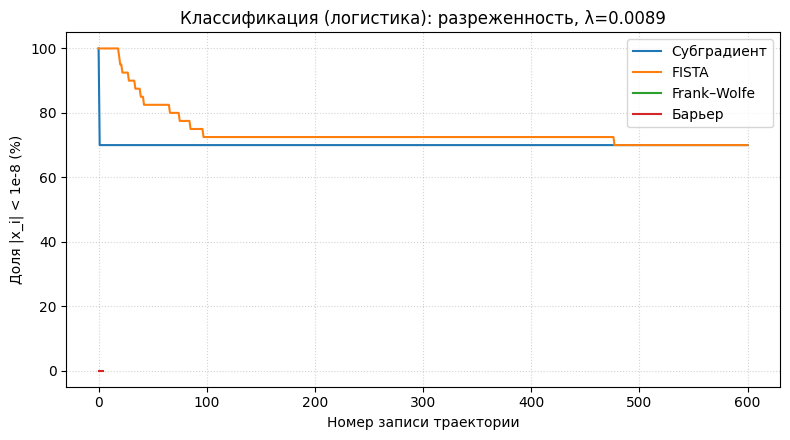

Сохранено C:\Users\axmed\OneDrive\Рабочий стол\proj\NothingElseMatters\figs\exp32_sparsity_classification.png


In [3]:
def run_four_methods_classification(m=120, n=40, max_iter=600, max_barrier_outer=35):
    A, y, _ = synthetic_classification(m, n, rng, sparsity=0.65)
    x0 = np.zeros(n)

    def build(lam):
        return ClassificationProxOracle(A, y, lam, l2_reg=0.0)

    lam, xref = tune_lambda_for_zero_fraction(
        build, n, x0, target_low=0.52, target_high=0.78, max_iter_fista=3500
    )
    R = radius_from_reference(xref, scale=1.04)
    print("[классификация] λ =", lam, "R =", R)

    comp = CountedCompositeOracle(ClassificationProxOracle(A, y, lam, l2_reg=0.0))
    nons = CountedNonsmoothOracle(ClassificationNonsmoothOracle(A, y, lam, l2_reg=0.0))
    sm = CountedSmoothOracle(ClassificationProxOracle(A, y, lam, l2_reg=0.0).smooth)

    h = {}
    _, _, h["subgrad"] = subgradient_method(
        nons, x0, max_iter=max_iter, alpha_0=0.35, trace=True, zero_thresh=ZERO_THRESH
    )
    _, _, h["fista"] = proximal_fast_gradient_method(
        comp, x0, max_iter=max_iter, tolerance=1e-12, trace=True, zero_thresh=ZERO_THRESH
    )
    _, _, h["fw"] = frank_wolfe_method(
        sm,
        x0,
        R,
        max_iter=max_iter,
        step_size_strategy="armijo",
        trace=True,
        lambda_l1=lam,
        zero_thresh=ZERO_THRESH,
    )
    u0 = np.abs(x0) + 1.0
    _, _, h["barrier"] = barrier_method(
        sm,
        x0,
        u0,
        lam,
        t_0=1.0,
        mu=8.0,
        max_iter=max_barrier_outer,
        max_inner_iter=80,
        tolerance_inner=5e-5,
        tolerance_outer=5e-2,
        trace=True,
        zero_thresh=ZERO_THRESH,
    )
    return lam, R, h


lam_c, R_c, hist_c = run_four_methods_classification()

plt.figure(figsize=(8, 4.5))
for name, lab in [("subgrad", "Субградиент"), ("fista", "FISTA"), ("fw", "Frank–Wolfe"), ("barrier", "Барьер")]:
    s = hist_c[name]["zero_frac"]
    plt.plot(np.arange(len(s)), s, label=lab)
plt.xlabel("Номер записи траектории")
plt.ylabel("Доля |x_i| < 1e-8 (%)")
plt.title(f"Классификация (логистика): разреженность, λ={lam_c:.4f}")
plt.legend()
plt.grid(True, ls=":", alpha=0.55)
plt.tight_layout()
p = FIG / "exp32_sparsity_classification.png"
plt.savefig(p, dpi=160, bbox_inches="tight")
plt.show()
print("Сохранено", p)

**Ответы для отчёта (кратко).**  
- **Точные нули без порога** дают проксимальный шаг (ISTA/FISTA: soft-thresholding) и, при попадании на ребро/вершину L1-шара, Frank–Wolfe как выпуклая комбинация вершин с ровно одной ненулевой координатой.  
- **Субградиент** не обнуляет координаты: шаг $x-\alpha g$ не является пороговым оператором, траектория осциллирует вокруг границы subdiff по нулю.  
- **Барьер** по построению держит строгое неравенство $u_i>|x_i|$, внутренняя точка никогда не даёт ровно нулевой вес до предела $t\to\infty$; в логах выше нули считаются по порогу на $x$ после проекции на физические веса.